In [7]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

sns.set_theme()
DATA_FOLDER = '../../data/'

In [ ]:
# Additional preprocessing was done by supervisor

df = pd.read_csv(os.path.join(DATA_FOLDER, 'EWZ_Daily_Preprocessed.csv'))

df.head()

,Name,Wärmezähler UST 10 Spitalstrasse 6 Regionalspital Surselva WZ11,Wärmezähler Fernleitung WZ6,Wärmezähler UST 01 Bahnhofstrasse 14,Wärmezähler UST 11 Via Schlifras 46,Wärmezähler UST 12 Via Schlifras 48,Wärmezähler UST 13 Via Schlifras 50,Wärmezähler UST 14 Via Schlifras 54,Wärmezähler UST 15 Solaranlage BWW,Wärmezähler UST 16 Via Schlifras 66/68/70,...,Wärmezähler UST 52 Städtlistrasse 3 / Rathausgasse 2,Wärmezähler UST 53 Via Rolf Maibach 4,"Wärmezähler UST 54 Spitalstrasse 2, Haus Theresia/Fidel",Wärmezähler UST 55 Via Schlifras 71,Wärmezähler UST 56 Via Hans Erni 10,Wärmezähler UST 57 Via Hans Erni 4,Wärmezähler UST 58 Via Schlifras 73,Wärmezähler UST 59 Via Schlifras 45,Wärmezähler UST 60 Via Hans Erni 8,Wärmezähler UST 61 Via Schlifras 55
0,2016-04-01,1.6835,15.7920,0.3020,0.084,0.125,0.180,0.166,0.1387,0.2795,...,0.2369,0.096,0.1894,0.0480,0.0578,0.053,0.035,0.020,0.0521,0.0626
1,2016-04-02,1.8121,16.9004,0.3200,0.088,0.150,0.196,0.195,0.1464,0.3320,...,0.2544,0.115,0.2166,0.0660,0.0532,0.062,0.037,0.028,0.0470,0.0684
2,2016-04-03,1.6738,15.9902,0.3000,0.080,0.155,0.159,0.148,0.1312,0.2750,...,0.2252,0.077,0.1785,0.0510,0.0610,0.077,0.034,0.027,0.0413,0.0700
3,2016-04-04,1.7487,15.7100,0.2790,0.079,0.158,0.171,0.185,0.1335,0.2490,...,0.2302,0.096,0.1435,0.0626,0.0524,0.056,0.035,0.019,0.0451,0.0600
4,2016-04-05,1.7051,15.1992,0.2848,0.080,0.130,0.179,0.162,0.1493,0.2600,...,0.2218,0.112,0.1820,0.0484,0.0576,0.052,0.032,0.027,0.0448,0.0630


In [3]:
corr = df.drop(columns=['Name'], inplace=False).corr().values

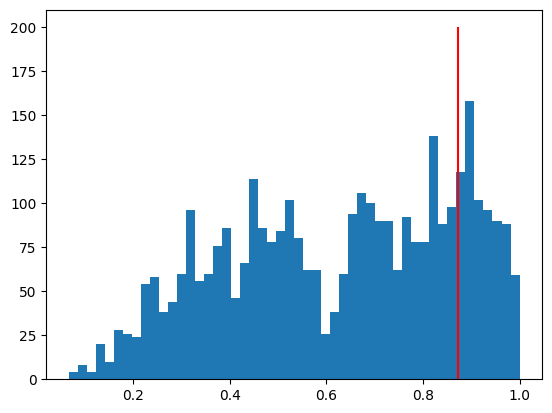

In [4]:
plt.hist(corr.flatten(), bins=50)
quantile = np.quantile(np.abs(corr), 0.8)
plt.vlines(x=quantile, ymin=0, ymax=200, color='red')
plt.show()

Sparsity rate: 0.7998


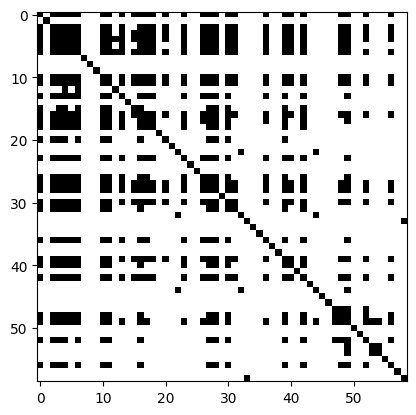

In [5]:
threshold = quantile

adj_matrix = (np.abs(corr) >= threshold).astype(int)
# np.fill_diagonal(adj_matrix, 0.) # supervisor said self loops

sparsity_rate = np.sum(adj_matrix == 0) / adj_matrix.size
print(f"Sparsity rate: {sparsity_rate:.4f}")

plt.imshow(adj_matrix, cmap='Greys',  interpolation='nearest')


In [ ]:
all_val = df.drop(columns=['Name'], inplace=False).values
T, V = all_val.shape
all_val = all_val.reshape(T, V, 1)

print(all_val.shape)

DIFFSTG_PATH = '../diffstg/data/dataset/ewz_daily/'
# np.save(os.path.join(DIFFSTG_PATH, 'flow.npy'), all_val)
# np.save(os.path.join(DIFFSTG_PATH, 'adj.npy'), adj_matrix)

(3501, 59, 1)


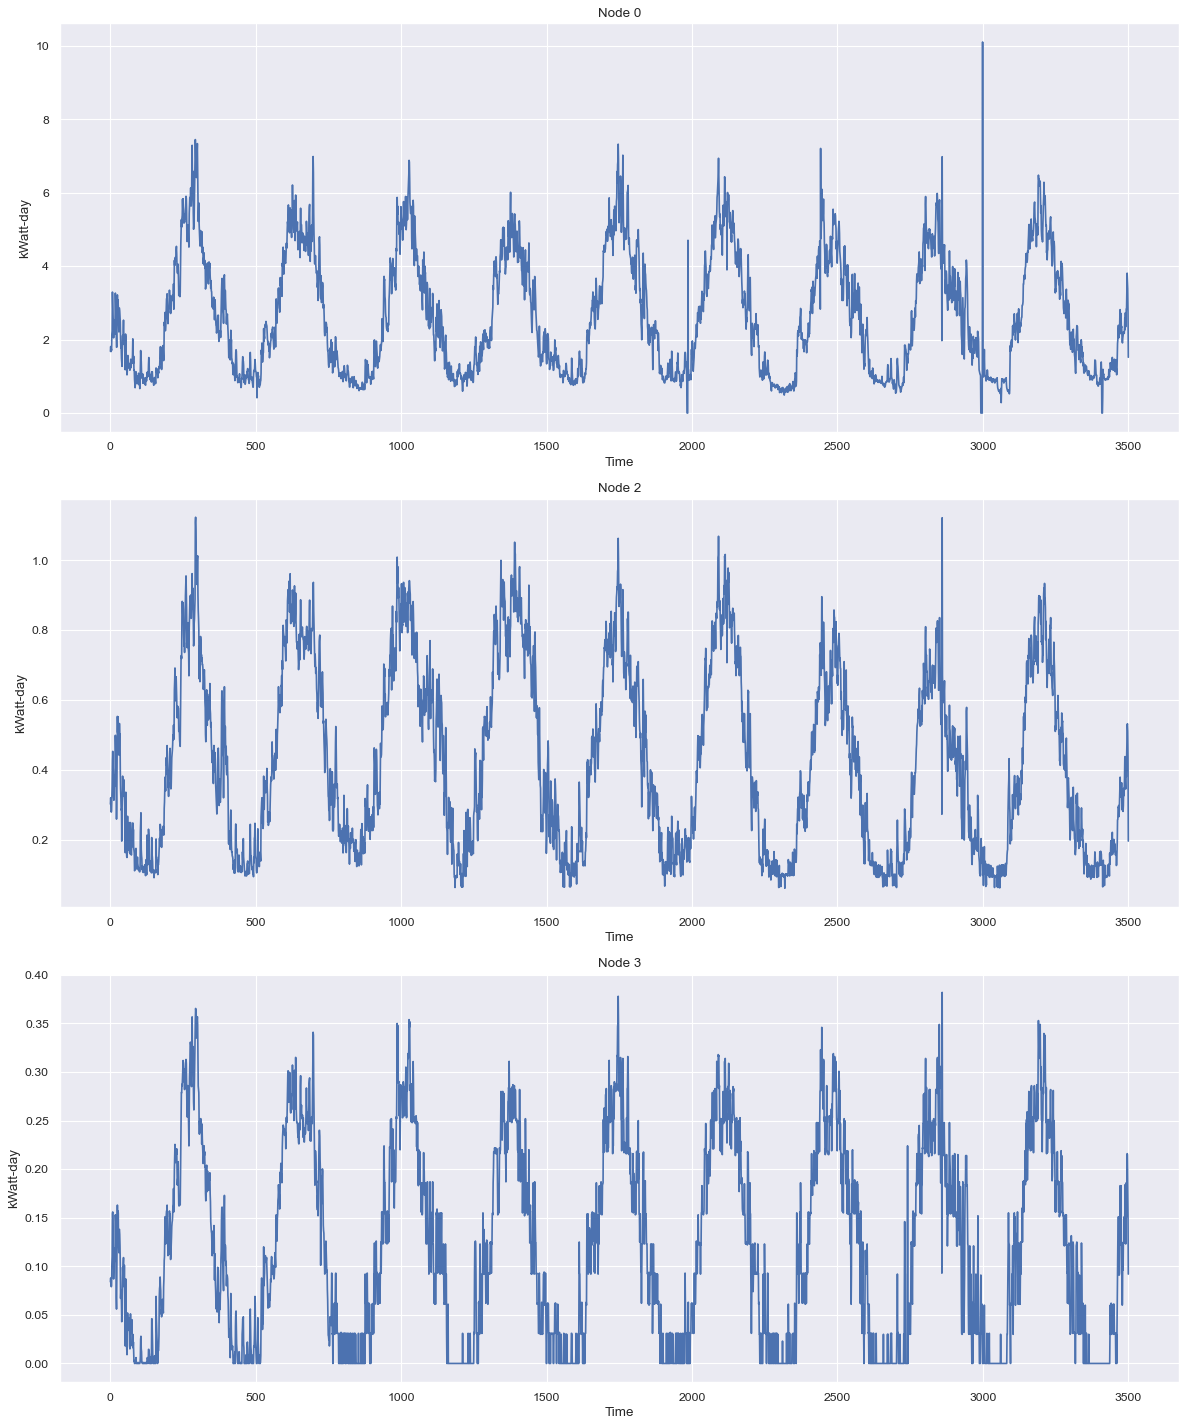

In [8]:
flow = np.load('../diffstg/data/dataset/ewz_daily/flow.npy')

fig, axes = plt.subplots(3, 1, figsize=(15, 18), dpi=80)

nodes_toplot = [0, 2, 3]
for idx, node_idx in enumerate(nodes_toplot):
    axes[idx].plot(flow[:, node_idx, 0])
    axes[idx].set_title(f"Node {node_idx}")
    axes[idx].set_xlabel("Time")
    axes[idx].set_ylabel("kWatt-day")

plt.tight_layout()
plt.savefig('../diffstg/plot/ewz.pdf')
plt.show()